0_Importazione librerie

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


1_Data Exploration & Preprocessing

In [6]:
# caricamento dataset e visualizzazione delle caratteristiche principali

data = load_wine()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="class")

df = X.copy()
df["class"] = y

print(df.describe())
print(df.groupby("class").size())


          alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000          17.200000   88.000000   
50%     13.050000    1.865000    2.360000          19.500000   98.000000   
75%     13.677500    3.082500    2.557500          21.500000  107.000000   
max     14.830000    5.800000    3.230000          30.000000  162.000000   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count     178.000000  178.000000            178.000000       178.000000   
mean        2.295112    2.029270              0.361854         1.590899   
std         0.625851    0.998859              0.124453         0.572359   
min         0.9

In [8]:
# standardizzazione delle feature

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

2_Data Dimensionality Reduction

In [9]:
# applicazione pca sulle feature per ridurre a 2 componenti principali

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

3_Addestramento e valutazione

In [15]:
# addestramento modello con knn su dati ridotti con pca e visualizzazione accuracy

k = 3
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_pca, y)
y_pred_knn = knn.predict(X_pca)
accuracy_knn = accuracy_score(y, y_pred_knn)
print(f"L'accuracy del modello con il K-NN:\t{accuracy_knn:.4f}")


L'accuracy del modello con il K-NN:	0.9719


In [16]:
# addestramento modello con svm (kernel=linear) su dati ridotti con pca e visualizzazione accuracy

svc = SVC(kernel="linear", C=1.0, random_state=42)
svc.fit(X_pca, y)
y_pred_svc = svc.predict(X_pca)
accuracy_svc = accuracy_score(y, y_pred_svc)
print(f"L'accuracy del modello con il K-NN:\t{accuracy_svc:.4f}")

L'accuracy del modello con il K-NN:	0.9719


4_Analisi & Visualizzazione

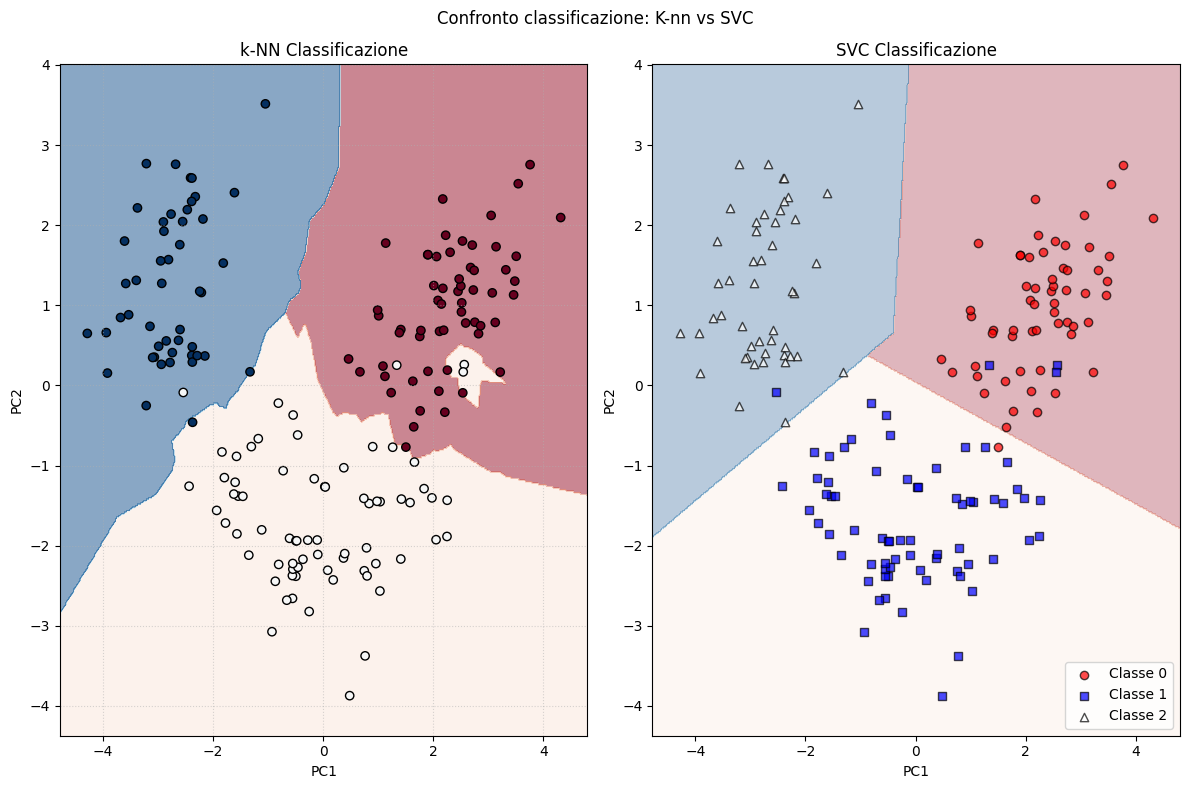

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(12,8))
plt.suptitle("Confronto classificazione: K-nn vs SVC")

# impostiamo i valori del piano cartesiano come valori max e min delle feature con PCA
x_min, x_max = X_pca[:, 0].min() - 0.5, X_pca[:, 0].max() + 0.5
y_min, y_max = X_pca[:, 1].min() - 0.5, X_pca[:, 1].max() + 0.5
# griglia rettangolare con punti equispaziati
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))


# creazione del subplot per knn
Z_knn = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax[0].contourf(xx, yy, Z_knn, alpha=0.5, cmap=plt.cm.RdBu)
ax[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, edgecolors="k", cmap=plt.cm.RdBu)
ax[0].set_title("k-NN Classificazione")
ax[0].set_xlabel("PC1")
ax[0].set_ylabel("PC2")
ax[0].set_xlim(xx.min(), xx.max())
ax[0].set_ylim(yy.min(), yy.max())
ax[0].grid(True, linestyle=":", alpha=0.5)

# creazione del subplot per svc
Z_svc = svc.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax[1].contourf(xx, yy, Z_svc, alpha= 0.3, cmap=plt.cm.RdBu)
ax[1].scatter(X_pca[y==0, 0], X_pca[y==0, 1], c ="red", edgecolors="k", marker="o", label="Classe 0", alpha = 0.7)
ax[1].scatter(X_pca[y==1, 0], X_pca[y==1, 1], c ="blue", edgecolors="k", marker="s", label="Classe 1", alpha = 0.7)
ax[1].scatter(X_pca[y==2, 0], X_pca[y==2, 1], c="white", edgecolors="k", marker="^", label="Classe 2", alpha=0.7)
ax[1].set_title("SVC Classificazione")
ax[1].set_xlabel("PC1")
ax[1].set_ylabel("PC2")
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()